The objective of this notebook is to find N the total number of particles between 1 and 5000 um using cumulative sum for Ueda25 raw data. First, we bin the data into different bin patterns. Second, we aply the cumulative sum method. We aspire to find the same N for all binning paterns.

In [1]:
import numpy as np                       
import matplotlib.pyplot as plt 
from scipy.stats import linregress
import pandas as pd

In [10]:
# Binning and cumulative sum
def cumulative_sum(bins_cs, samplings_cs):
    """ Bins particles into chosen bins. Plots cumulative sum with dependance on lower bin limit.
        Returns cumulative sum counts in each bin for all sampling campaigns.  """

    
    cumulative_counts_all_samplings = []
    for i in range(len(samplings_cs)):
        lower_bin_limits = bins_cs[i]
        cumulative_counts = np.array([(samplings_cs[i] >= limit).sum() for limit in lower_bin_limits])
        cumulative_counts_all_samplings.append(cumulative_counts)
 
        fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 3))

        ax1.plot(lower_bin_limits, cumulative_counts, marker='o')
        ax1.set_xlabel('Lower bin limit')
        ax1.set_ylabel("Cumulative counts")
        ax1.set_title('Normal distribution')

        ax2.loglog(lower_bin_limits, cumulative_counts, marker='o')
        ax2.set_xlabel('Log lower bin limit')
        ax2.set_ylabel("log cumulative counts")
        ax2.set_title('Log log scale distribution')
    
    return cumulative_counts_all_samplings
    

In [11]:
def finding_N(minimal_bins_used_fN, cumulative_counts_all_samplings_fN, lower_bin_limits_fN):
   
    """ Erases the tail of the distribution and computes the slope and intercept and computes N. """
    
    slopes_cumsum_all_samplings = []
    intercepts_cumsum_all_samplings = []
    N_all_samplings=[]
    slopes_all_samplings=[]
    for i in range(len(cumulative_counts_all_samplings_fN)):
        minimal_bins_used=minimal_bins_used_fN[i]
        bins_used=lower_bin_limits_fN[i]
        # Adjusting the tail
        counts = cumulative_counts_all_samplings_fN[i]
        if len(counts) < minimal_bins_used:
            print('Problem: There is not enough bins to do linear regression!', minimal_bins_used)
            continue
        counts_kept = counts[:minimal_bins_used]
        bins_kept = bins_used[:minimal_bins_used]
        if counts_kept[-1] < 1:
            print('Problem: There is not enough particles in the last bin')
            continue
            
        # Finding slope & intercept of cumulative distribution
        log_bins_kept = np.log10(bins_kept)
        log_counts_kept = np.log10(counts_kept)
        log_bins = np.log10(bins_used)
        log_counts = np.log10(counts)
        slope_cumsum, intercept_cumsum, *_ = linregress(log_bins_kept, log_counts_kept) ### *_ ignores following variables
        slopes_cumsum_all_samplings.append(slope_cumsum)
        intercepts_cumsum_all_samplings.append(intercept_cumsum)
        
        plt.figure(figsize=(4,4))
        plt.scatter(log_bins,log_counts,marker='o',label='Full distribution')
        plt.scatter(log_bins_kept,log_counts_kept,marker='o',label='Used for linear regression')
        plt.plot(log_bins,slope_cumsum*log_bins+intercept_cumsum, label='Linear regression', color='green')
        plt.xlabel('Log lower bin limit')
        plt.ylabel("Log cumulative counts")
        plt.title('Log log scale size distribution')
        plt.legend()
        plt.show()

        # Comparing with initial slope
        slope = slope_cumsum - 1
        slopes_all_samplings.append(slope)
        # Computing N the total number of particles
    slopes_cumsum_all_samplings=np.array(slopes_cumsum_all_samplings)
    intercepts_cumsum_all_samplings=np.array(intercepts_cumsum_all_samplings)

    N_1 = slopes_cumsum_all_samplings*np.log10(1)+intercepts_cumsum_all_samplings
    N_5000=slopes_cumsum_all_samplings*np.log10(5000)+intercepts_cumsum_all_samplings
    N_all_samplings = 10**N_1-10**N_5000


    return {'N': N_all_samplings, 'slope': slopes_all_samplings, 'intercept':10**intercepts_cumsum_all_samplings }



In [4]:
raw_data = pd.read_csv('Ueda25_pump_fragments_all_sites.csv',sep=';')
raw_data 

,pump site A,pump site B,pump site C,pump site D
0,21.213,21.213,21.213,21.2130
1,21.213,21.213,21.213,21.2130
2,21.213,21.213,21.213,21.2130
3,21.213,21.213,21.213,21.2130
4,21.213,21.213,21.213,21.2130
...,...,...,...,...
2214,NaN,NaN,NaN,472.1987
2215,NaN,NaN,NaN,503.3034
2216,NaN,NaN,NaN,551.0000
2217,NaN,NaN,NaN,593.0766


In [5]:
size_distribution_A=raw_data['pump site A'].dropna()
size_distribution_B=raw_data['pump site B'].dropna()
size_distribution_C=raw_data['pump site C'].dropna()
size_distribution_D=raw_data['pump site D'].dropna()
size_distributions=[size_distribution_A,size_distribution_B,size_distribution_C,size_distribution_D]


### Site A
We define the sampling parameters describing the particles size distribution such as LOD and number of particles. The LOD are the smallest and the biggest particle measured.

In [7]:
# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 21
LOD_high = 503

# Sampling
number_of_particles=(len(size_distribution_A))
all_samplings=[]
all_samplings.append(size_distribution_A)

One can choose which bin to use in this demonstration: regular_bins or irregular_bins to see the effect of binning on the results. For this exemple we choose irregular bins.
All samplings are stored in all_cumulative_counts.

In [8]:
# Irregular bins
step = 2
irregular_bins=[]
current_edge = LOD_low
edges = [current_edge]
bins_edges_all=[]
while True:
    next_step = step
    current_edge += next_step
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 2  # next step doubles
irregular_bins = edges
bins_edges_all.append(irregular_bins)

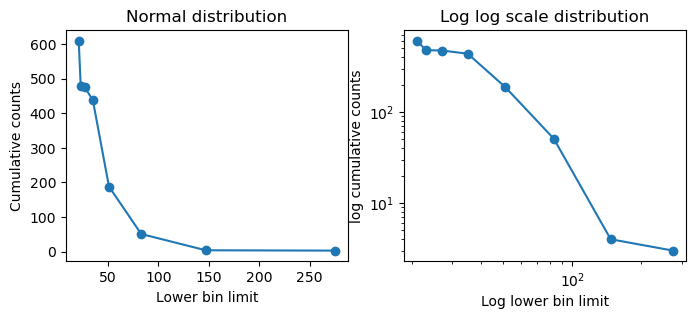

In [13]:
site_A_cumsum=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


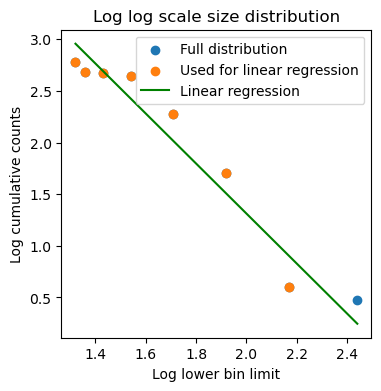

{'N': array([1475477.64632957]),
 'slope': [np.float64(-3.4285401748490933)],
 'intercept': array([1475477.64786361])}

In [14]:
finding_N(minimal_bins_used_fN=np.array([7]), cumulative_counts_all_samplings_fN=site_A_cumsum, lower_bin_limits_fN=bins_edges_all)


### All sites 

In [15]:
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 21
LOD_high = np.array([503,1495,562,658])

# Sampling
number_of_particles=np.array([len(size_distribution_A),len(size_distribution_B),len(size_distribution_C),len(size_distribution_D)])
all_samplings=size_distributions


#### step * 2

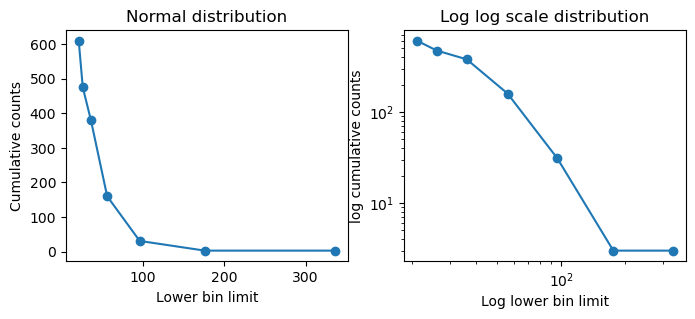

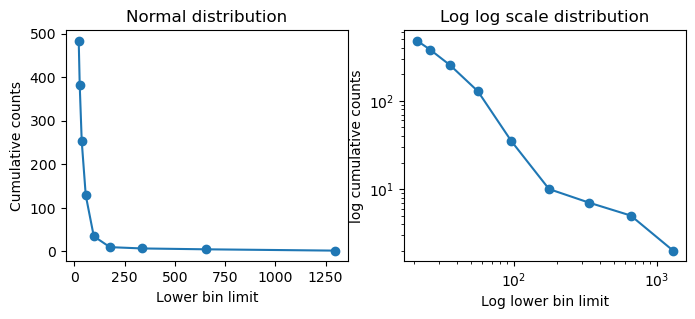

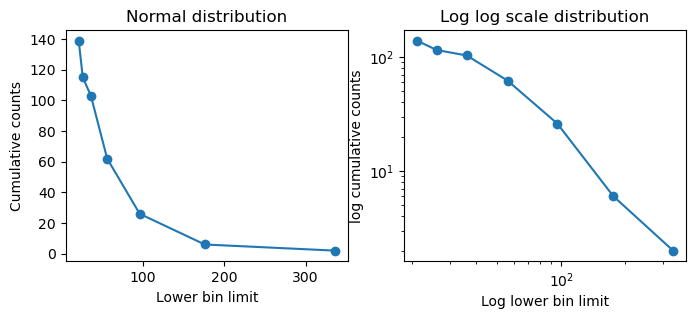

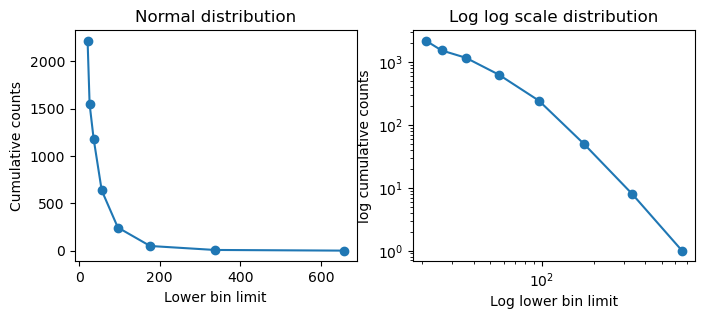

In [16]:
# Irregular bins
all_2_bins=[]
for i in range(len(LOD_high)):
    step = 5
    irregular_bins=[]
    current_edge = LOD_low
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high[i]:
            break
        edges.append(current_edge)
        step *= 2  # next step doubles
    irregular_bins = edges
    all_2_bins.append(irregular_bins)

cumsum_all_sites=cumulative_sum(bins_cs=all_2_bins,samplings_cs=all_samplings)


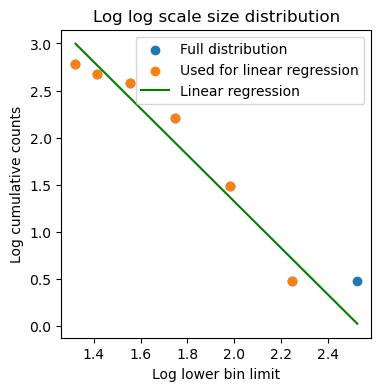

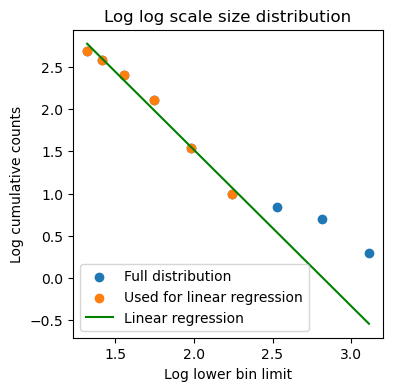

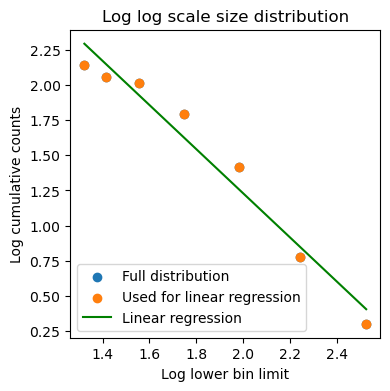

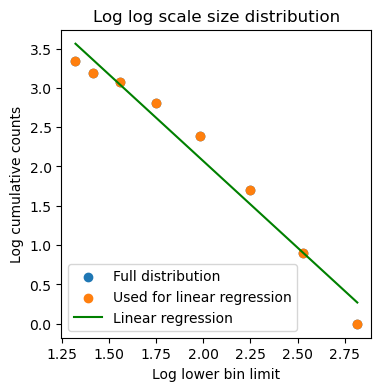

In [17]:
N_all_sites_step2=finding_N(minimal_bins_used_fN=np.array([6,6,7,8]), cumulative_counts_all_samplings_fN=cumsum_all_sites, lower_bin_limits_fN=all_2_bins)

recap_table_all_sites=pd.DataFrame({
    'Site' : ['A','B','C','D'],
    'Calculated Slope ' : N_all_sites_step2['slope'],
    'Calulated N' : N_all_sites_step2['N'],

})

comparison_table=pd.DataFrame({
    'Site' : ['A','B','C','D'],
    'Step * 2' : N_all_sites_step2['N'],
})

comparison_table_slope=pd.DataFrame({
    'Site' : ['A','B','C','D'],
    'Step * 2' : N_all_sites_step2['slope'],
})


In [18]:
recap_table_all_sites

,Site,Calculated Slope,Calulated N
0,A,-3.470124,1.834612e+06
1,B,-2.853091,1.681991e+05
2,C,-2.569343,2.339680e+04
3,D,-3.202429,2.976628e+06


#### Small regular bins

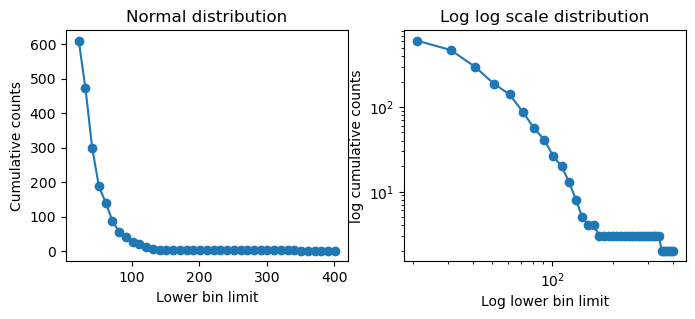

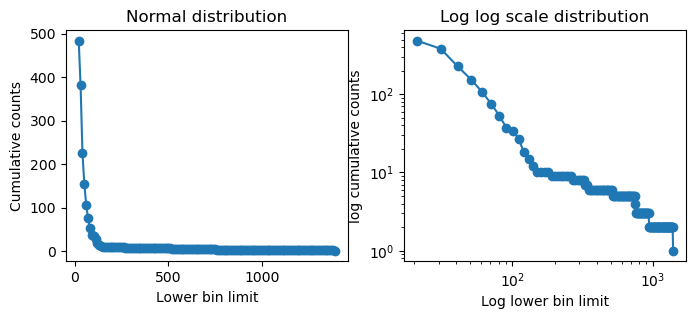

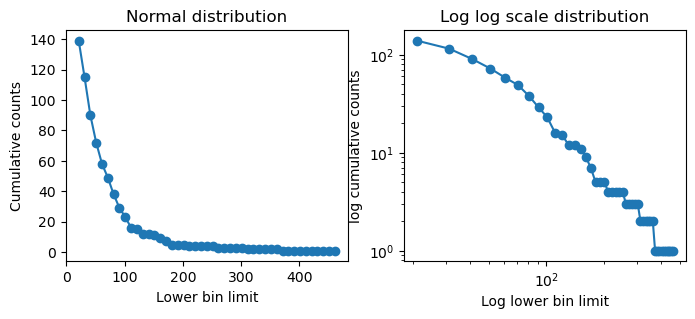

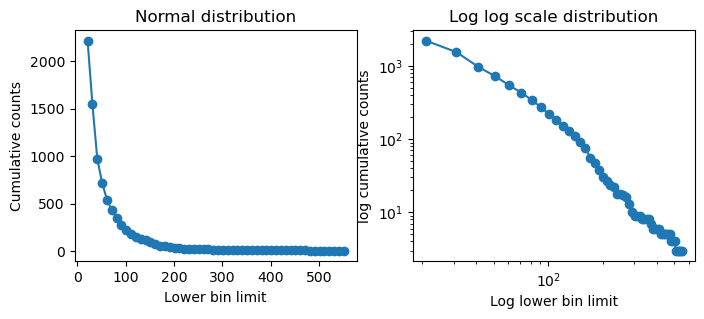

In [19]:
# Small regular bins
bin_length = 10
all_small_bins=[]
for i in range(len(LOD_high)):
    regular_bins = np.arange(LOD_low,LOD_high[i]+1-100,bin_length)
    all_small_bins.append(regular_bins)

cumsum_all_sites=cumulative_sum(bins_cs=all_small_bins,samplings_cs=all_samplings)

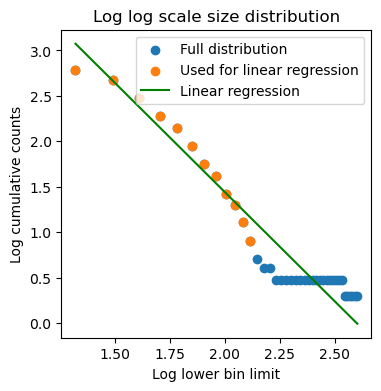

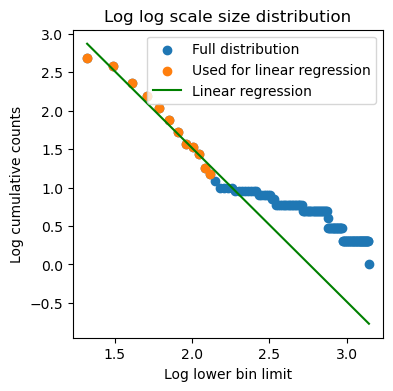

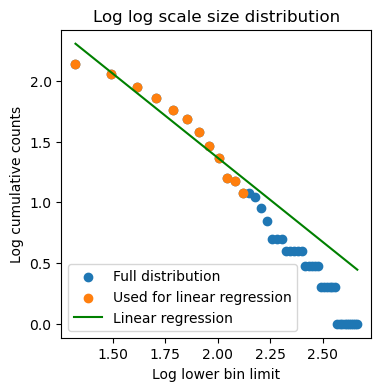

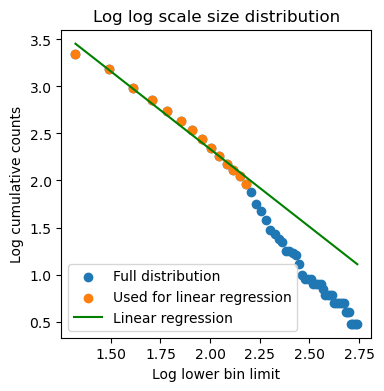

In [20]:
N_all_sites_small=finding_N(minimal_bins_used_fN=np.array([12,12,12,14]), cumulative_counts_all_samplings_fN=cumsum_all_sites, lower_bin_limits_fN=all_small_bins)
#comparison_table.insert(loc=1, column='Small bin', value=N_all_sites_small['N'])
comparison_table_slope.insert(loc=1, column='Small bin', value=N_all_sites_small['slope'])


#### Big bins

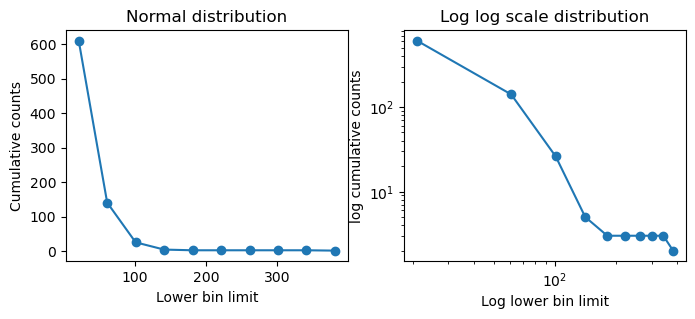

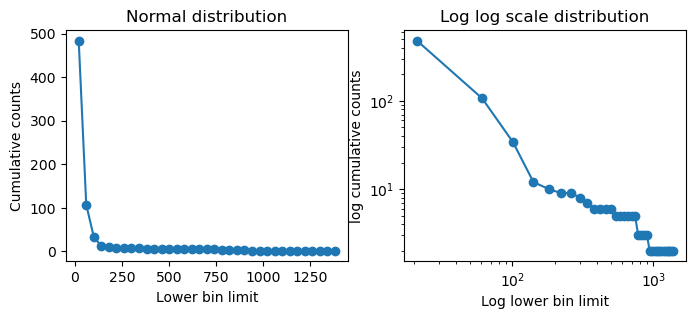

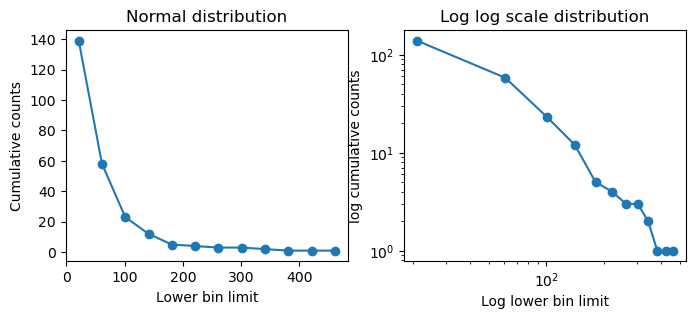

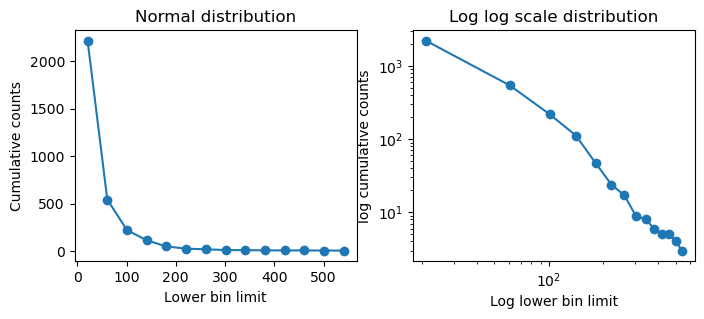

In [42]:
# Big regular bins
bin_length = 40
all_big_bins=[]
for i in range(len(LOD_high)):
    regular_bins = np.arange(LOD_low,LOD_high[i]+1-100,bin_length)
    all_big_bins.append(regular_bins)

cumsum_all_sites=cumulative_sum(bins_cs=all_big_bins,samplings_cs=all_samplings)


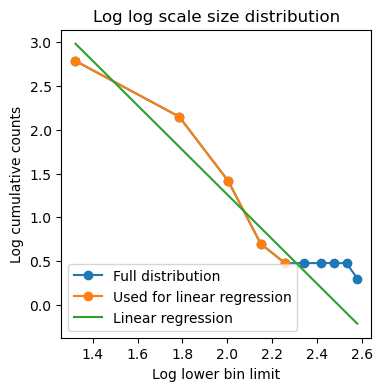

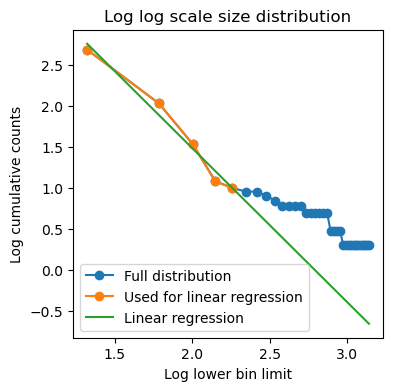

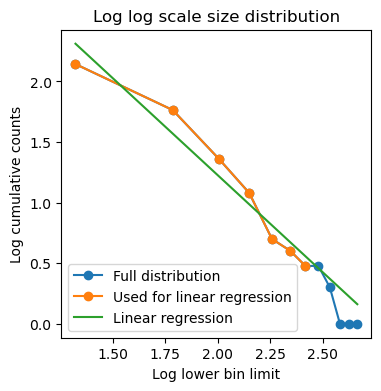

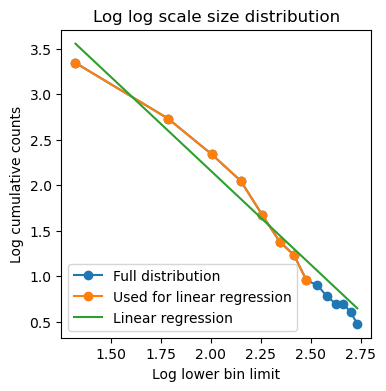

In [43]:
N_all_sites_big=finding_N(minimal_bins_used_fN=np.array([5,5,7,8]), cumulative_counts_all_samplings_fN=cumsum_all_sites, lower_bin_limits_fN=all_big_bins)
comparison_table.insert(loc=1, column='Big bin', value=N_all_sites_big['N'])
comparison_table_slope.insert(loc=1, column='Big bin', value=N_all_sites_big['slope'])


#### Step * 1,5 bins

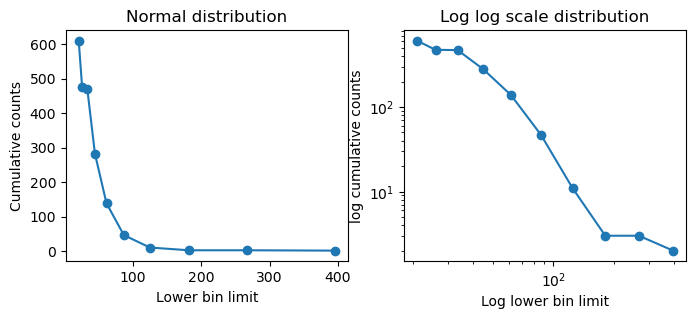

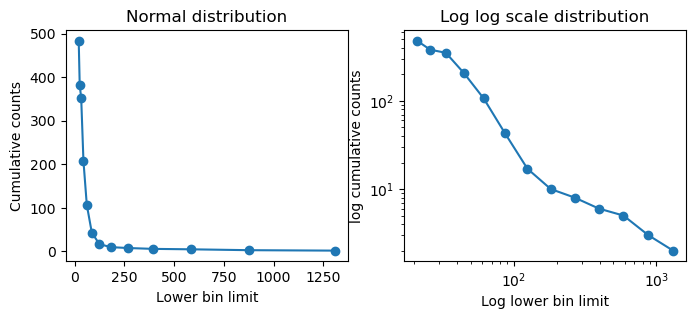

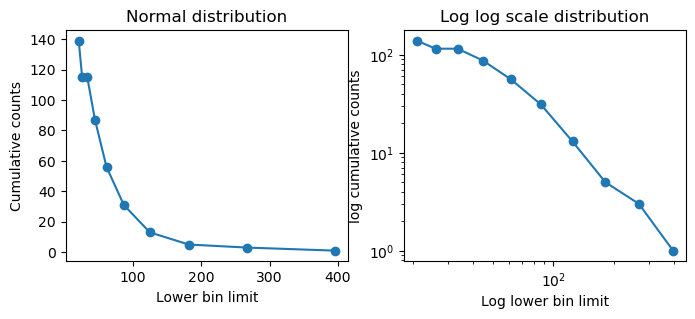

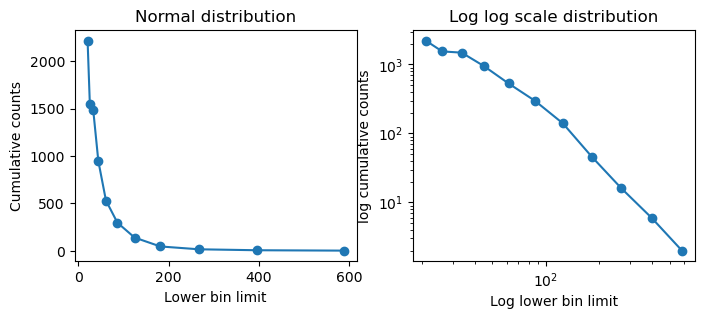

In [44]:
# Irregular bins
all_1_5_bins=[]
for i in range(len(LOD_high)):
    step = 5
    irregular_bins=[]
    current_edge = LOD_low
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high[i]:
            break
        edges.append(current_edge)
        step *= 1.5  # next step doubles
    irregular_bins = edges
    all_1_5_bins.append(irregular_bins)

cumsum_all_sites=cumulative_sum(bins_cs=all_1_5_bins,samplings_cs=all_samplings)



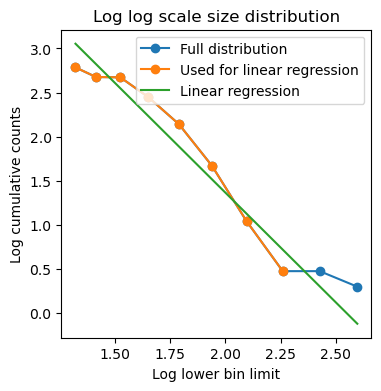

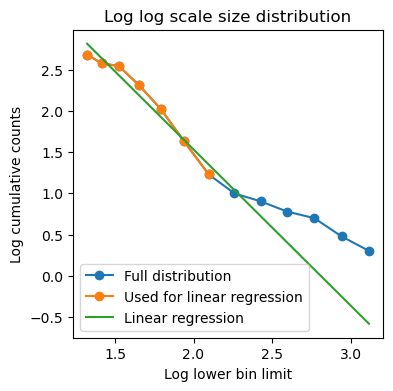

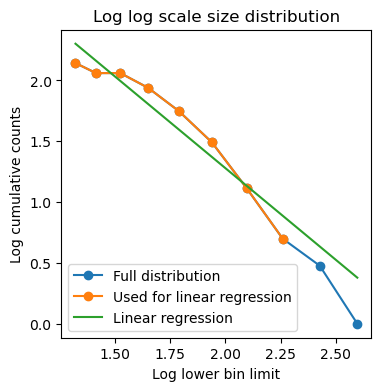

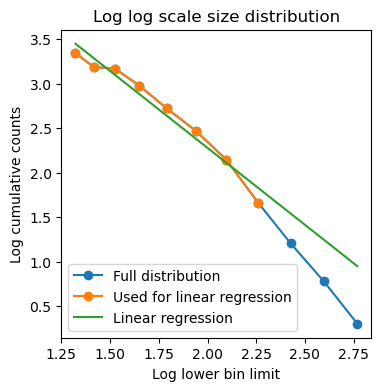

In [45]:
N_all_sites_1_5=finding_N(minimal_bins_used_fN=np.array([8,7,8,8]), cumulative_counts_all_samplings_fN=cumsum_all_sites, lower_bin_limits_fN=all_1_5_bins)
comparison_table.insert(loc=1, column='Step * 1.5', value=N_all_sites_1_5['N'])
comparison_table_slope.insert(loc=1, column='Step * 1.5', value=N_all_sites_1_5['slope'])


In [46]:
comparison_table_slope

,Site,Step * 1.5,Big bin,Small bin,Step * 2
0,A,-3.488437,-3.540074,-3.406209,-3.470124
1,B,-2.896707,-2.877957,-2.998530,-2.853091
2,C,-2.508726,-2.602758,-2.388151,-2.569343
3,D,-2.729252,-3.062699,-2.652354,-3.202429


/tmp/ipykernel_3188/1731347526.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(comparison_table_slope_2,


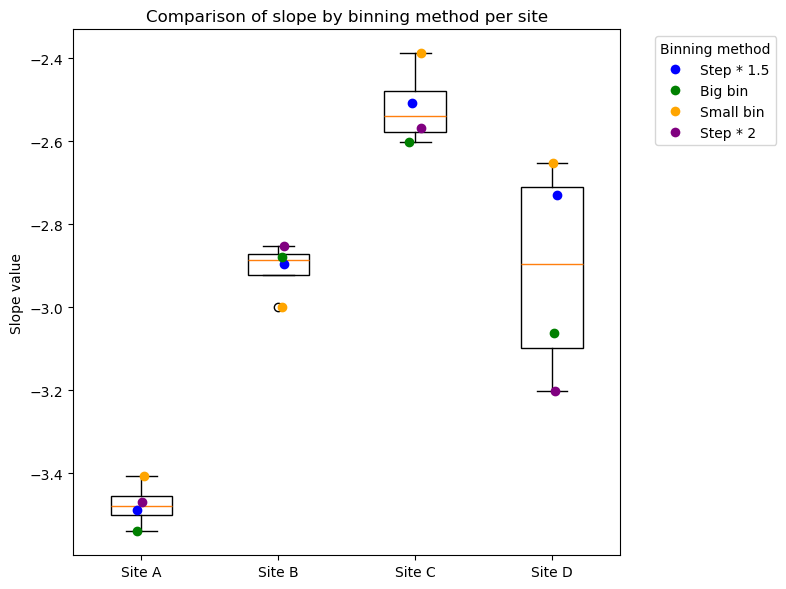

In [49]:
df=comparison_table_slope

# Set up
labels = ['Site A', 'Site B', 'Site C', 'Site D']
binning_methods = df.columns[1:]

# Data for boxplot (list of columns per site)
comparison_table_slope_2 = [df.iloc[i, 1:].values for i in range(len(df))]  # list of np.arrays, one per site

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_ylabel('Slope value')
ax.set_title('Comparison of slope by binning method per site')

# Boxplot
bplot = ax.boxplot(comparison_table_slope_2,
                   patch_artist=True,
                   labels=labels,
                  boxprops=dict(facecolor=(0,0,0,0)))

# Color map for binning strategies
color_map = {
    'Step * 1.5': 'blue',
    'Big bin': 'green',
    'Small bin': 'orange',
    'Step * 2': 'purple'
}

# Overlay points with color
for i, site in enumerate(df['Site']):
    for j, method in enumerate(binning_methods):
        y = df.loc[i, method]
        x = i + 1 + np.random.uniform(-0.05, 0.05)  # jitter for visibility
        ax.scatter(x, y, color=color_map[method], label=method if i == 0 else "", zorder=3)

# Make legend (only once per binning method)
handles = [plt.Line2D([0], [0], marker='o', color='w', label=method,
                      markerfacecolor=color_map[method], markersize=8)
           for method in color_map]
ax.legend(handles=handles, title='Binning method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()